In [1]:
############################# Cross Sections #############################
# The purpose of this notebook is to plot various cross-sections 
# of model output to characterize the domain and what is going 
# on.This notebook will look at a few corss sections in the 
# domine, plot averages, and potentially make movies of the 
# variables on interest. This notebook will include cross-
# sections of (1) salinity and temperature with density contours,
# (2) velocities, and (3) mixing and eddy viscosity/diffusivity.
#
# Notes:
# - This script runs in xroms 
# - This script heavily uses code from Dylan Schlichting 
# - 
#
########################################################################

In [2]:
# Load in the packages
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import warnings
import xarray as xr
import xroms
from matplotlib import ticker
import matplotlib.colors as colors
crs = ccrs.PlateCarree()
from joblib import Parallel, delayed
warnings.filterwarnings("ignore") #turns off annoying warnings
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

# The core of the analysis is done with xhistogram
from xhistogram.xarray import histogram

## Define Functions  
Make functions to help with processing the output

In [3]:
# Make a function to open the model output
def open_roms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_netcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [4]:
def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [5]:
# Make a function to calculate useful derivatives and add them back into 
# the dataset
def add_derivatives(ds, grid, q='salt'):
    '''
Analysis of velocity gradient tensor and frontogenesis function
following Hetland et al. (2025) JPO
    '''
    qs = ds[q]
    
    #############################
    # Flow and property gradients at the ocean surface
    
    ds['dqdx'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'X'), grid)    # defined at rho-points
    ds['dqdy'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'Y'), grid)    # defined at rho-points
    
    ds['dudx'] = grid.derivative(ds.isel(s_rho=-1).u, 'X', boundary='extend')  # defined at rho-points
    ds['dvdy'] = grid.derivative(ds.isel(s_rho=-1).v, 'Y', boundary='extend')  # defined at rho-points
    ds['dvdx'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).v, 'X', boundary='extend'), grid)  # defined at rho-points
    ds['dudy'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).u, 'Y', boundary='extend'), grid)  # defined at rho-points
    
    ###########################
    # Invariant flow properties
    
    # Vorticity:  v_x - u_y
    ds['zeta'] = (ds.dvdx - ds.dudy)/ds.f
    ds['zeta'].name = 'Normalized vorticity'

    # Divergence: u_x + v_y
    ds['delta'] = (ds.dudx + ds.dvdy)/ds.f
    ds['delta'].name = 'Normalized divergence'

    # Major axis of deformation
    ds['alpha'] = ( np.sqrt( (ds.dudx-ds.dvdy)**2 + (ds.dvdx+ds.dudy)**2 ) )/ds.f
    ds['alpha'].name = 'Normalized total strain'

    ##################################
    # Principle deformation components

    ds['lminor'] = 0.5 * (ds.delta - ds.alpha)
    ds['lminor'].name = 'lambda minor'

    ds['lmajor'] = 0.5 * (ds.delta + ds.alpha)
    ds['lmajor'].name = 'lambda major'
    
    #############################################
    # Along- and cross-frontal velocity gradients
    
    # angle is wrt x, so need to do arctan2(y, x)
    ds['phi_cf'] = np.arctan2(ds.dqdy, ds.dqdx)
    ds['phi_af'] = ds.phi_cf + np.pi/2.0

    ds['du_cf'] = ( ds.dudx*np.cos(ds.phi_cf)**2 + ds.dvdy*np.sin(ds.phi_cf)**2 
               + (ds.dudy + ds.dvdx)*np.sin(ds.phi_cf)*np.cos(ds.phi_cf) )/ds.f

    ds['du_af'] = ( ds.dudx*np.cos(ds.phi_af)**2 + ds.dvdy*np.sin(ds.phi_af)**2
              + (ds.dudy + ds.dvdx)*np.sin(ds.phi_af)*np.cos(ds.phi_af) )/ds.f
    
    ############################
    # The frontogenesis function
    
    # Dimensional frontogenesis function
    Dgradq_i = - ds.dudx*ds.dqdx - ds.dvdx*ds.dqdy
    Dgradq_j = - ds.dudy*ds.dqdx - ds.dvdy*ds.dqdy
    ds['Ddelq2'] = (ds.dqdx*Dgradq_i + ds.dqdy*Dgradq_j)
    ds['Ddelq2'].name = 'Frontogenesis function'

    # Density gradients squared
    ds['gradq2'] = ds.dqdx**2 + ds.dqdy**2
    ds['gradq2'].name = r'$(\nabla q)^2$'

    # Normalized frontogenesis function
    ds['nFGF'] = 0.5 * ds.Ddelq2 / (ds.gradq2 * ds.f)
    ds['nFGF'].name = r'Normalized Frontogenesis Function'
    
    return ds

In [6]:
def to_rho(var):
    if var.dims[-1] != 'xi_rho':
        var = grid.interp(var, 'X', to='center', boundary='extend')
    if var.dims[-2] != 'eta_rho':
        var = grid.interp(var, 'Y', to='center', boundary='extend')
    return var

In [7]:
def velgrad(ds,grid):
    '''
    Calculates flow invariants vorticity, divergence, strain
    '''
    us = ds.u 
    vs = ds.v

    dudx = grid.derivative(us, 'X', boundary='extend')
    dvdy = grid.derivative(vs, 'Y', boundary='extend')
    dudy = to_rho(grid.derivative(us, 'Y', boundary='extend'))
    dvdx = to_rho(grid.derivative(vs, 'X', boundary='extend'))
    # Vorticity:  v_x - u_y
    rv = (dvdx - dudy)/ds.f
    rv.name = 'Normalized vorticity'

    # Divergence: u_x + v_y
    delta = (dudx + dvdy)/ds.f
    delta.name = 'Normalized divergence'

    # Major axis of deformation
    alpha = ( np.sqrt( (dudx-dvdy)**2 + (dvdx+dudy)**2 ) )/ds.f
    alpha.name = 'Normalized strain'
    
    return rv,delta,alpha

## Process the Output  
Load in and process the model output

In [8]:
# Set the path to the desired model output

# Constant forcing (time series), ice, U3C4, K-eps
#path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps*.nc')

# Constant forcing, U3C4, k-epsilon
grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc')
# Constant forcing, U3C4, gen
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc')
# Constant forcing, U3C4, kkl
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc')
# Constant forcing, U3C4, k-omega
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_komegaaltkmin_*.nc')
# Constant forcing, U3C4, kpp
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc')

In [9]:
# Load in the output from above with xroms
ds, grid = open_mfroms(path)
add_derivatives(ds, grid)

<xarray.Dataset> Size: 6TB
Dimensions:             (tracer: 8, s_rho: 40, s_w: 41, eta_rho: 1002,
                         xi_rho: 402, eta_v: 1001, xi_u: 401, ocean_time: 1440)
Coordinates: (12/21)
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w                 (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.025 0.0
    x_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    x_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    y_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    ...                  ...
    z_w_v               (ocean_time, s_w, eta_v, xi_rho) float64 190GB dask.array<chunksize=(1, 41, 1001, 402), meta=np.ndarray>
    z_w_psi             (ocean_time, s_w, eta_v, xi_u) float64 190GB dask.array<chunksize=(1, 41, 1001, 401), meta=np.ndarray>
    z_rho               (ocean_time, s_rho, eta_rho, xi_rho) float64 186GB dask.array<chunksize=(1, 40, 1002, 402), meta=np.ndarray>
    z_rho_u             (ocean_time, s_rho, eta_rho, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1002, 401), meta=np.ndarray>
    z_rho_v             (ocean_time, s_rho, eta_v, xi_rho) float64 185GB dask.array<chunksize=(1, 40, 1001, 402), meta=np.ndarray>
    z_rho_psi           (ocean_time, s_rho, eta_v, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1001, 401), meta=np.ndarray>
Dimensions without coordinates: tracer
Data variables: (12/168)
    ntimes              int32 4B ...
    ndtfast             int32 4B ...
    dt                  float64 8B ...
    dtfast              float64 8B ...
    dstart              object 8B ...
    nHIS                int32 4B ...
    ...                  ...
    phi_af              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_cf               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_af               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    Ddelq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    gradq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    nFGF                (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
Attributes: (12/29)
    file:              /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/rom...
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS nonlinear model averages file
    title:             Idealized Alaskan beaufort shelf sea jet
    var_info:          /pscratch/sd/d/dylan617/roms/ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.30/ofi/gnu/12.3/bin/mpif90
    compiler_flags:    -frepack-arrays -mcmodel=large -fallow-argument-mismat...
    tiling:            16x32
    history:           ROMS, Version 4.3, Thursday - January 1, 2026 -  7:17:...
    ana_file:          /global/homes/d/dylan617/beaufort_jet/project/Function...
    CPP_options:       BEAUFORT_JET_ICE_BULK_FLUXES_W_DVD, ANA_BPFLUX, ANA_BS...

In [10]:
grid_nc = xr.open_dataset(grd_file)

In [11]:
# Calculate some submesoscale things 
# (relative vorticity (rv), gradient normalized by Coriolos (delta), 
# and ...axis of deformation? (alpha))
rv, delta, alpha = velgrad(ds, grid)

In [12]:
# Calculate distance in km
# to use for plotting 
# Can use x_rho, y_rho, x_u, y_u, etc. but those are a 
# little wonky...sooooo calculate it yourself I guess
# (I think if we read in the grid directly then they will
# be fixed? but are weird in the output? No clue but do manually
# for now)
dx = ds.x_rho[0,2].values - ds.x_rho[0,1].values
print('dx: ', dx)
dy = ds.y_rho[1,0].values - ds.y_rho[0,0].values
print('dy: ', dy)

len_xi_rho = len(ds.xi_rho.values)
print('len_xi_rho: ' , len_xi_rho)
len_eta_rho = len(ds.eta_rho)
print('len_eta_rho: ', len_eta_rho)

x_rho = np.arange(0, len_xi_rho*dx, dx)
print('x_rho: ', x_rho[-10:-1])
print('ds.x_rho: ', ds.x_rho[0,-10:-1].values)

y_rho = np.arange(0, len_eta_rho*dy, dy)
print('y_rho: ', y_rho[-10:-1])
print('ds.y_rho: ', ds.y_rho[-10:-1,0].values)

x_u = x_rho[:-1]
y_u = np.copy(y_rho)
x_v = np.copy(x_rho)
y_v = y_rho[:-1]

dx:  500.0
dy:  500.0
len_xi_rho:  402
len_eta_rho:  1002
x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
ds.x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]
ds.y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]


In [13]:
# Make a time to use ?


In [14]:
rv

<xarray.DataArray 'Normalized vorticity' (ocean_time: 1440, s_rho: 40,
                                          eta_rho: 1002, xi_rho: 402)> Size: 186GB
dask.array<truediv, shape=(1440, 40, 1002, 402), dtype=float64, chunksize=(1, 40, 1002, 402), chunktype=numpy.ndarray>
Coordinates:
  * s_rho       (s_rho) float64 320B -0.9875 -0.9625 -0.9375 ... -0.0375 -0.0125
  * xi_rho      (xi_rho) int64 3kB 0 1 2 3 4 5 6 ... 395 396 397 398 399 400 401
  * eta_rho     (eta_rho) int64 8kB 0 1 2 3 4 5 6 ... 996 997 998 999 1000 1001
  * ocean_time  (ocean_time) object 12kB 0001-01-01 01:00:00 ... 0001-04-30 2...
    x_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
Attributes:
    standard_name:  sea_water_y_velocity
    long_name:      v-momentum component
    units:          meter second-1
    time:           ocean_time
    cell_methods:   ocean_time: mean
    grid:           grid
    location:       edge2
    field:          v-velocity

In [15]:
# Set the transect locations (across-shelf)
x_tran1 = np.where(x_rho == 50000)
x_tran1 = int(x_tran1[0])
print(x_tran1)
x_tran2 = np.where(x_rho == 100000)
x_tran2 = int(x_tran2[0])
print(x_tran2)
x_tran3 =  np.where(x_rho == 150000)
x_tran3 = int(x_tran3[0])
print(x_tran3)

100
200
300


Text(0.5, 1.0, 'Surface Relative Vorticity on Day: 0001-01-13')

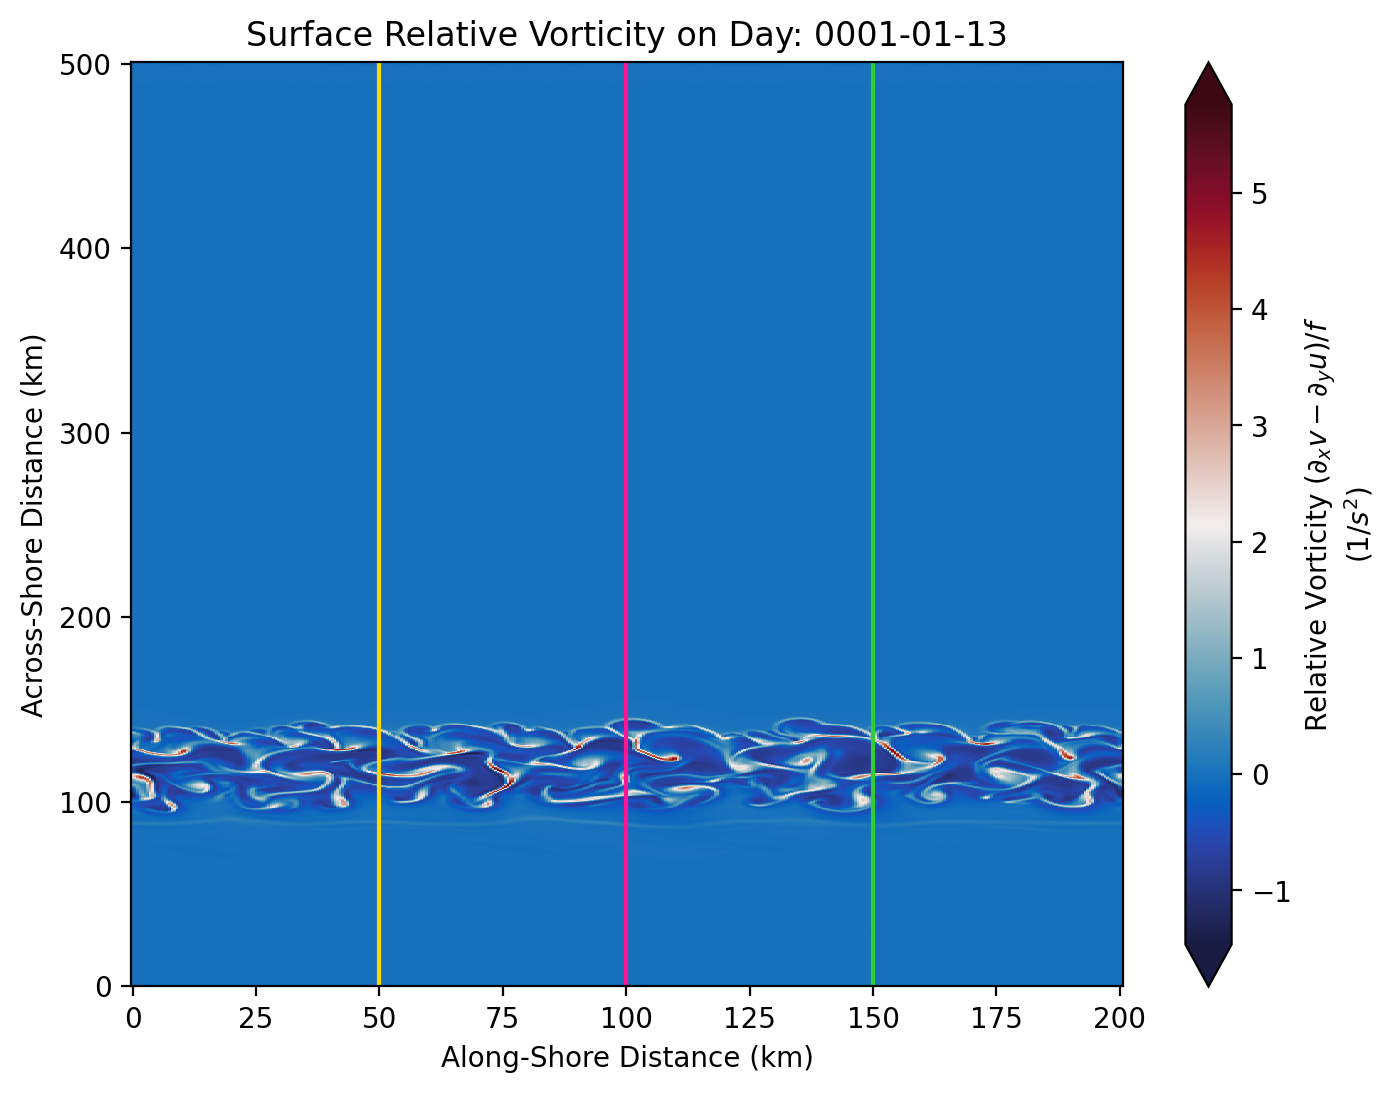

In [16]:
# Plot the domain and pick the cross sections we want to look at 

# Set the time index to look at 
time_idx1 = 150

# Set the levels 
lev_vort = np.arange(-1, 1, 0.01)

# Make the figure 
fig, ax  = plt.subplots(figsize=(8,6), dpi=200)

# Plot vorticity to pick our cross-sections 
p1 = ax.pcolormesh(x_rho/1000, y_rho/1000, rv[time_idx1, -1, :, :],
               cmap=cmo.balance)

# Add a colorbar
fig.colorbar(p1, extend='both').set_label('Relative Vorticity $(\partial_x v - \partial_y u)/f$ \n($1/s^{2}$)')

# Plot transects 
plt.axvline(x_rho[x_tran1]/1000, color='gold', linewidth=1.5, label='Transect 1')
plt.axvline(x_rho[x_tran2]/1000, color='deeppink', linewidth=1.5, label='Transect 2')
plt.axvline(x_rho[x_tran3]/1000, color='limegreen', linewidth=1.5, label='Transect 3')

# Label the axes
ax.set_xlabel('Along-Shore Distance (km)')
ax.set_ylabel('Across-Shore Distance (km)')
ax.set_title('Surface Relative Vorticity on Day: ' + str(ds.ocean_time.values[time_idx1])[:10])


In [17]:
# Probably don't want to plot to the end of the domain but stick around the jet area 
# and maybe nearshore of that, too, just to see what's happening in shallow
# depths 

## Salinity, Temperature, and Density

In [18]:
ds.z_rho

<xarray.DataArray 'z_rho' (ocean_time: 1440, s_rho: 40, eta_rho: 1002,
                           xi_rho: 402)> Size: 186GB
dask.array<transpose, shape=(1440, 40, 1002, 402), dtype=float64, chunksize=(1, 40, 1002, 402), chunktype=numpy.ndarray>
Coordinates:
  * s_rho       (s_rho) float64 320B -0.9875 -0.9625 -0.9375 ... -0.0375 -0.0125
    x_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
  * ocean_time  (ocean_time) object 12kB 0001-01-01 01:00:00 ... 0001-04-30 2...
  * xi_rho      (xi_rho) int64 3kB 0 1 2 3 4 5 6 ... 395 396 397 398 399 400 401
  * eta_rho     (eta_rho) int64 8kB 0 1 2 3 4 5 6 ... 996 997 998 999 1000 1001
    z_rho       (ocean_time, s_rho, eta_rho, xi_rho) float64 186GB dask.array<chunksize=(1, 40, 1002, 402), meta=np.ndarray>
Attributes:
    long_name:      depth of RHO-points
    time:           ocean_time
    field:          z_rho, scalar, series
    units:          m
    positive:       up
    standard_name:  depth

[None, None, None, None, None]

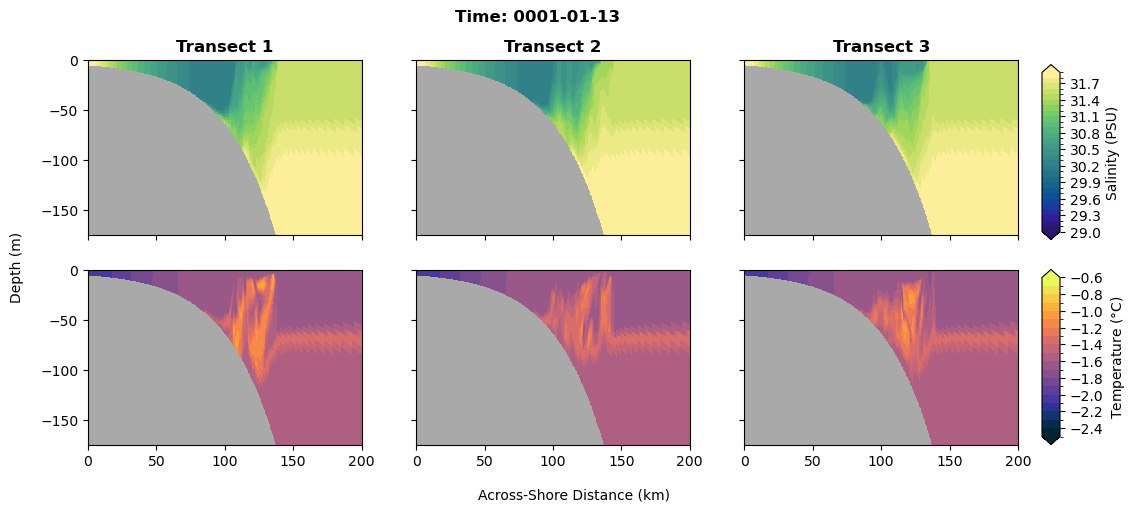

In [19]:
# Plot the salinity and tempature at these transects
# at that time index

# Set the levels
lev_salt = np.arange(29, 32, 0.1)
lev_temp = np.arange(-2.5, -0.5, 0.1)

# Set the colormaps
cmap_salt = cmo.haline
cmap_temp = cmo.thermal

# Define the normalization instance
# ncolors specifies how many color intervals the cmap should be split into
norm_salt = BoundaryNorm(lev_salt, ncolors=cmap_salt.N, clip=True)
norm_temp = BoundaryNorm(lev_temp, ncolors=cmap_temp.N, clip=True)

# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(12,5))

# Plot salinity
# Transect 1
p1 = ax[0,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], ds.salt[time_idx1,:,:,x_tran1],
                        cmap=cmap_salt, norm=norm_salt)
# Transect 2
p2 = ax[0,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], ds.salt[time_idx1,:,:,x_tran2],
                        cmap=cmap_salt, norm=norm_salt)
# Transect 3
p3 = ax[0,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], ds.salt[time_idx1,:,:,x_tran3],
                        cmap=cmap_salt, norm=norm_salt)
# Add colorbar
#plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
cbar_ax1 = fig.add_axes([0.92,0.52,0.015,0.35])
fig.colorbar(p3,ax=ax,extend='both', label='Salinity (PSU)',
             pad=0.03, cax=cbar_ax1)


# Plot temperature 
# Transect 1
p4 = ax[1,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], ds.temp[time_idx1,:,:,x_tran1],
                        cmap=cmap_temp, norm=norm_temp)
# Transect 2
p5 = ax[1,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], ds.temp[time_idx1,:,:,x_tran2],
                        cmap=cmap_temp, norm=norm_temp)
# Transect 3
p6 = ax[1,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], ds.temp[time_idx1,:,:,x_tran3],
                        cmap=cmap_temp, norm=norm_temp)
# Add colorbar
#plt.colorbar(p6, ax=[ax[1,0], ax[1,1], ax[1,2]], extend='both').set_label('Temperature (C)')
cbar_ax2 = fig.add_axes([0.92,0.11,0.015,0.35])
fig.colorbar(p6,ax=ax,extend='both', label='Temperature ($\degree$C)',
             pad=0.03, cax=cbar_ax2)

# Add density contours...

# Set limits to focus on the jet
for r in range(3):
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)
        ax[j,r].set_facecolor('darkgray')

# Label the plots/axes
ax[0,0].set_title('Transect 1', weight='bold')
ax[0,1].set_title('Transect 2', weight='bold')
ax[0,2].set_title('Transect 3', weight='bold')
fig.suptitle('Time: ' + str(ds.ocean_time[time_idx1].values)[:10], weight='bold')
fig.text(0.45, 0.001, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)


In [20]:
# Calculate density (xroms - uses nonlinear eos)
roms_density_xroms = xroms.roms_seawater.density(ds.temp, ds.salt, z=None)

In [21]:
roms_density_xroms[time_idx1,:,:,x_tran1].max().values

array(1036.58666224)

In [22]:
# Calculate density again but using linear equation of state 
# Set the coefficients/reference values from ROMS output
R0 = ds.R0.values # kg/m3
T0 = 0.5 # Celsius
S0 = 31  # nondimensional
T_coeff = ds.Tcoef.values # 1/Celsius
S_coeff = ds.Scoef.values # 1/nondimensional

# Now calculate density
roms_density = R0 * (1 - (T_coeff*(ds.temp-T0)) + (S_coeff*(ds.salt-S0)))

# Add this to the xarray dataset
#ds['roms_density'] = (['ocean_time', 's_rho', 'eta_rho', 'xi_rho'], roms_density.values)


In [23]:
R0

array(1027.)

[None, None, None, None, None]

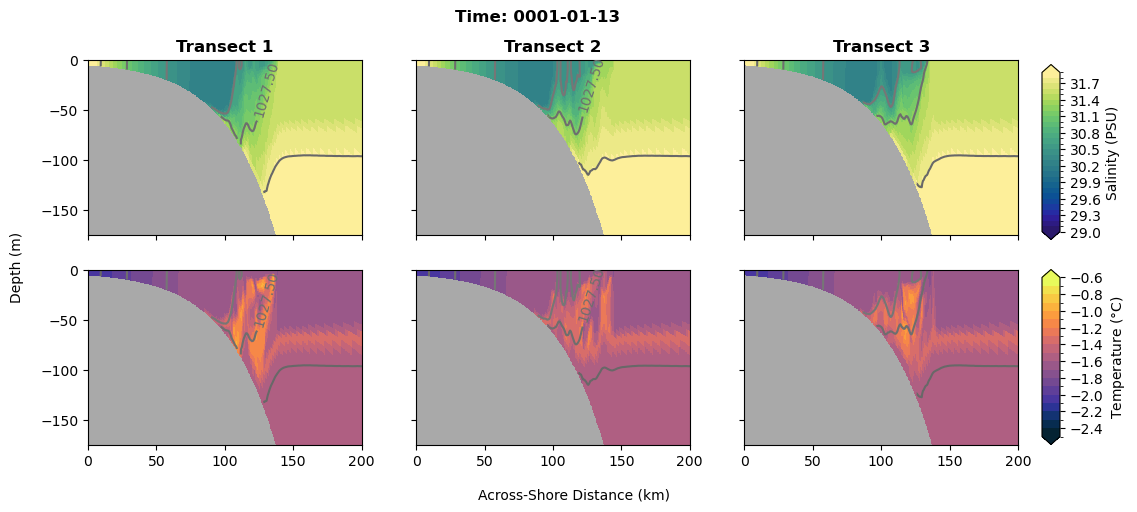

In [24]:
# Make same plot but with density contours
# Set the levels
lev_salt = np.arange(29, 32, 0.1)
lev_temp = np.arange(-2.5, -0.5, 0.1)
lev_dens = np.arange(1015, 1035, 0.5)

# Set the colormaps 
cmap_salt = cmo.haline
cmap_temp = cmo.thermal

# Define the normalization instance
# ncolors specifies how many color intervals the cmap should be split into
norm_salt = BoundaryNorm(lev_salt, ncolors=cmap_salt.N, clip=True)
norm_temp = BoundaryNorm(lev_temp, ncolors=cmap_temp.N, clip=True)

# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(12,5))

# Plot salinity
# Transect 1
p1 = ax[0,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], ds.salt[time_idx1,:,:,x_tran1],
                        cmap=cmap_salt, norm=norm_salt)
# Transect 2
p2 = ax[0,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], ds.salt[time_idx1,:,:,x_tran2],
                        cmap=cmap_salt, norm=norm_salt)
# Transect 3
p3 = ax[0,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], ds.salt[time_idx1,:,:,x_tran3],
                        cmap=cmap_salt, norm=norm_salt)
# Add colorbar
#plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
cbar_ax1 = fig.add_axes([0.92,0.52,0.015,0.35])
fig.colorbar(p3,ax=ax,extend='both', label='Salinity (PSU)',
             pad=0.03, cax=cbar_ax1)


# Plot temperature 
# Transect 1
p4 = ax[1,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], ds.temp[time_idx1,:,:,x_tran1],
                        cmap=cmap_temp, norm=norm_temp)
# Transect 2
p5 = ax[1,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], ds.temp[time_idx1,:,:,x_tran2],
                        cmap=cmap_temp, norm=norm_temp)
# Transect 3
p6 = ax[1,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], ds.temp[time_idx1,:,:,x_tran3],
                        cmap=cmap_temp, norm=norm_temp)
# Add colorbar
#plt.colorbar(p6, ax=[ax[1,0], ax[1,1], ax[1,2]], extend='both').set_label('Temperature (C)')
cbar_ax2 = fig.add_axes([0.92,0.11,0.015,0.35])
fig.colorbar(p6,ax=ax,extend='both', label='Temperature ($\degree$C)',
             pad=0.03, cax=cbar_ax2)

# Set limits to focus on the jet
# Loop through columns
for r in range(3):
    # Loop through rows
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)

        # Set the facecolor
        ax[j,r].set_facecolor('darkgray')

        # Plot density contours
        if r == 0: 
            y_2d = np.tile(y_rho, (ds.z_rho[time_idx1,:,:,x_tran1].shape[0], 1))
            c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx1,:,:,x_tran1], roms_density[time_idx1,:,:,x_tran1],
                 levels=lev_dens, cmap='Greys')
            ax[j,r].clabel(c1, inline=True, fmt='%1.2f')
        if r == 1: 
            y_2d = np.tile(y_rho, (ds.z_rho[time_idx1,:,:,x_tran2].shape[0], 1))
            c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx1,:,:,x_tran2], roms_density[time_idx1,:,:,x_tran2],
                 levels=lev_dens, cmap='Greys')
            ax[j,r].clabel(c1, inline=True, fmt='%1.2f')
        if r == 2:
            y_2d = np.tile(y_rho, (ds.z_rho[time_idx1,:,:,x_tran3].shape[0], 1))
            c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx1,:,:,x_tran3], roms_density[time_idx1,:,:,x_tran3],
                 levels=lev_dens, cmap='Greys')
            ax[j,r].clabel(c1, inline=True, fmt='%1.2f')



# Label the plots/axes
ax[0,0].set_title('Transect 1', weight='bold')
ax[0,1].set_title('Transect 2', weight='bold')
ax[0,2].set_title('Transect 3', weight='bold')
fig.suptitle('Time: ' + str(ds.ocean_time[time_idx1].values)[:10], weight='bold')
fig.text(0.45, 0.001, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)


In [26]:
# Definitely make movies of this because this is looking crazzzyyyyy

In [25]:
# Make a movie of the verison with density 
# Define a function to make the plots
# Now define function to plot the movie
def plot_salt_temp_trans(time_idx):
    i = time_idx // 1
    #print('i: ', i)
    #print('time_idx: ', time_idx)

    # Set the levels
    lev_salt = np.arange(29, 32, 0.1)
    lev_temp = np.arange(-2.5, -0.5, 0.1)
    lev_dens = np.arange(1015, 1035, 0.5)

    # Set the colormaps 
    cmap_salt = cmo.haline
    cmap_temp = cmo.thermal

    # Define the normalization instance
    # ncolors specifies how many color intervals the cmap should be split into
    norm_salt = BoundaryNorm(lev_salt, ncolors=cmap_salt.N, clip=True)
    norm_temp = BoundaryNorm(lev_temp, ncolors=cmap_temp.N, clip=True)

    # Make the figure 
    fig, ax = plt.subplots(2, 3, figsize=(12,5))

    # Plot salinity
    # Transect 1
    p1 = ax[0,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], ds.salt[time_idx,:,:,x_tran1],
                            cmap=cmap_salt, norm=norm_salt)
    # Transect 2
    p2 = ax[0,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran2], ds.salt[time_idx,:,:,x_tran2],
                            cmap=cmap_salt, norm=norm_salt)
    # Transect 3
    p3 = ax[0,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran3], ds.salt[time_idx,:,:,x_tran3],
                            cmap=cmap_salt, norm=norm_salt)
    # Add colorbar
    #plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
    cbar_ax1 = fig.add_axes([0.92,0.52,0.015,0.35])
    fig.colorbar(p3,ax=ax,extend='both', label='Salinity (PSU)',
                pad=0.03, cax=cbar_ax1)


    # Plot temperature 
    # Transect 1
    p4 = ax[1,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], ds.temp[time_idx,:,:,x_tran1],
                            cmap=cmap_temp, norm=norm_temp)
    # Transect 2
    p5 = ax[1,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran2], ds.temp[time_idx,:,:,x_tran2],
                            cmap=cmap_temp, norm=norm_temp)
    # Transect 3
    p6 = ax[1,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran3], ds.temp[time_idx,:,:,x_tran3],
                            cmap=cmap_temp, norm=norm_temp)
    # Add colorbar
    #plt.colorbar(p6, ax=[ax[1,0], ax[1,1], ax[1,2]], extend='both').set_label('Temperature (C)')
    cbar_ax2 = fig.add_axes([0.92,0.11,0.015,0.35])
    fig.colorbar(p6,ax=ax,extend='both', label='Temperature ($\degree$C)',
                pad=0.03, cax=cbar_ax2)

    # Set limits to focus on the jet
    # Loop through columns
    for r in range(3):
        # Loop through rows
        for j in range(2):
            # Set the limits
            ax[j,r].set_xlim(0,200)
            ax[j,r].set_ylim(-175,0)

            # Set the facecolor
            ax[j,r].set_facecolor('darkgray')

            # Plot density contours
            if r == 0: 
                y_2d = np.tile(y_rho, (ds.z_rho[time_idx,:,:,x_tran1].shape[0], 1))
                c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx,:,:,x_tran1], roms_density[time_idx,:,:,x_tran1],
                    levels=lev_dens, cmap='Greys')
                ax[j,r].clabel(c1, inline=True, fmt='%1.2f')
            if r == 1: 
                y_2d = np.tile(y_rho, (ds.z_rho[time_idx,:,:,x_tran2].shape[0], 1))
                c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx,:,:,x_tran2], roms_density[time_idx,:,:,x_tran2],
                    levels=lev_dens, cmap='Greys')
                ax[j,r].clabel(c1, inline=True, fmt='%1.2f')
            if r == 2:
                y_2d = np.tile(y_rho, (ds.z_rho[time_idx,:,:,x_tran3].shape[0], 1))
                c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx,:,:,x_tran3], roms_density[time_idx,:,:,x_tran3],
                    levels=lev_dens, cmap='Greys')
                ax[j,r].clabel(c1, inline=True, fmt='%1.2f')



    # Label the plots/axes
    ax[0,0].set_title('Transect 1', weight='bold')
    ax[0,1].set_title('Transect 2', weight='bold')
    ax[0,2].set_title('Transect 3', weight='bold')
    fig.suptitle('Time: ' + str(ds.ocean_time[time_idx].values)[:10], weight='bold')
    fig.text(0.45, 0.001, 'Across-Shore Distance (km)')
    fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

    # Hide some axis labels 
    plt.setp(ax[0,1].get_xticklabels(), visible=False)
    plt.setp(ax[0,1].get_yticklabels(), visible=False)
    plt.setp(ax[0,2].get_xticklabels(), visible=False)
    plt.setp(ax[0,2].get_yticklabels(), visible=False)
    plt.setp(ax[0,0].get_xticklabels(), visible=False)
    plt.setp(ax[1,1].get_yticklabels(), visible=False)
    plt.setp(ax[1,2].get_yticklabels(), visible=False)

    # Comment this out if you are printing a lot of frames... jupyter will be unhappy
    #print(f'/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Movies/Surf_temp_salt_vort_ice/Plots01/surf_temp_salt_aice_icethick_rvort_tnum_{i}.png')
   
    plt.savefig(
        f'/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Movies/Salt_temp_dens/Plots01/salt_temp_dens_trans_500m_span_500km_const_u3c4_keps_{i}.png',
        dpi=200, bbox_inches='tight'
    )
    plt.close(fig)  # Close to avoid memory leaks


In [26]:
# Call the function to make the plots for the movie
#Parallel(n_jobs=4)(delayed(plot_salt_temp_trans)(time_idx) for time_idx in range(0, len(ds.ocean_time), 1))

## Velocities 

In [27]:
# Plot transects of the velocities (particularly u)
# at these three transects 


In [28]:
# Put u and v on the rho grid first
u_rho = to_rho(ds.u)
v_rho = to_rho(ds.v)

[None, None, None, None, None]

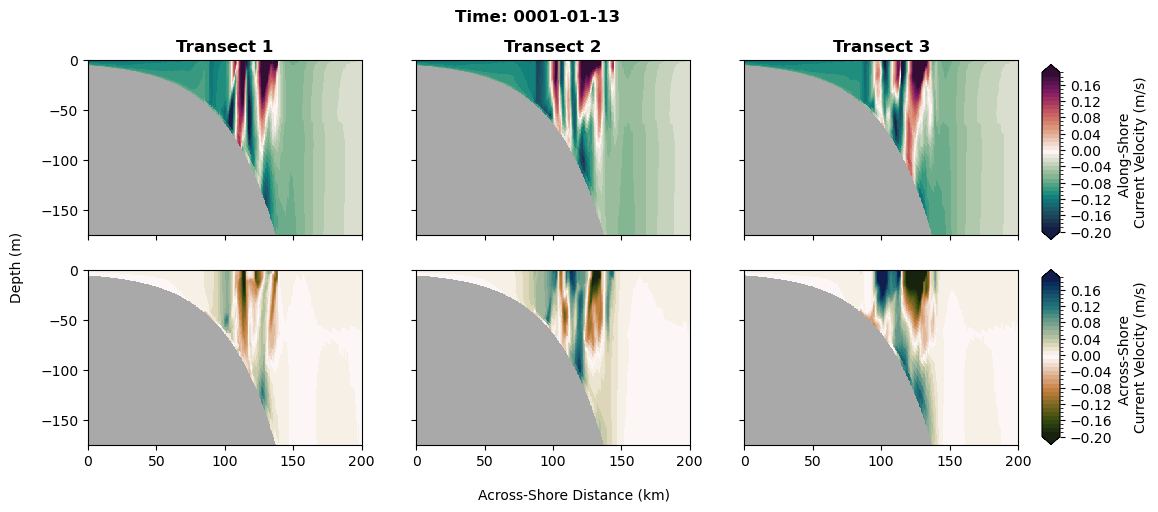

In [29]:
# Set the levels
lev_cur = np.arange(-0.2, 0.2, 0.01)

# Set the colormaps
cmap_u = cmo.curl
cmap_v = cmo.tarn

# Define the normalization instance
# ncolors specifies how many color intervals the cmap should be split into
norm_cur = BoundaryNorm(lev_cur, ncolors=cmap_u.N, clip=True)

# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(12,5))

# Plot u
# Transect 1
p1 = ax[0,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], u_rho[time_idx1,:,:,x_tran1],
                        cmap=cmap_u, norm=norm_cur)
# Transect 2
p2 = ax[0,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], u_rho[time_idx1,:,:,x_tran2],
                        cmap=cmap_u, norm=norm_cur)
# Transect 3
p3 = ax[0,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], u_rho[time_idx1,:,:,x_tran3],
                        cmap=cmap_u, norm=norm_cur)
# Add colorbar
#plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
cbar_ax1 = fig.add_axes([0.92,0.52,0.015,0.35])
fig.colorbar(p3,ax=ax,extend='both', label='Along-Shore \nCurrent Velocity (m/s)',
             pad=0.03, cax=cbar_ax1)


# Plot v 
# Transect 1
p4 = ax[1,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], v_rho[time_idx1,:,:,x_tran1],
                        cmap=cmap_v, norm=norm_cur)
# Transect 2
p5 = ax[1,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], v_rho[time_idx1,:,:,x_tran2],
                        cmap=cmap_v, norm=norm_cur)
# Transect 3
p6 = ax[1,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], v_rho[time_idx1,:,:,x_tran3],
                        cmap=cmap_v, norm=norm_cur)
# Add colorbar
#plt.colorbar(p6, ax=[ax[1,0], ax[1,1], ax[1,2]], extend='both').set_label('Temperature (C)')
cbar_ax2 = fig.add_axes([0.92,0.11,0.015,0.35])
fig.colorbar(p6,ax=ax,extend='both', label='Across-Shore \nCurrent Velocity (m/s)',
             pad=0.03, cax=cbar_ax2)

# Add density contours...

# Set limits to focus on the jet
for r in range(3):
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)
        ax[j,r].set_facecolor('darkgray')

# Label the plots/axes
ax[0,0].set_title('Transect 1', weight='bold')
ax[0,1].set_title('Transect 2', weight='bold')
ax[0,2].set_title('Transect 3', weight='bold')
fig.suptitle('Time: ' + str(ds.ocean_time[time_idx1].values)[:10], weight='bold')
fig.text(0.45, 0.001, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)

In [30]:
# Make a function to make a movie of this? NOt sure why 
# it took so long but see if there is a way to make this
# fasterrrr


In [31]:
# Make a movie of the verison with density 
# Define a function to make the plots
# Now define function to plot the movie
def plot_u_v_trans(time_idx, cmap_u, cmap_v, norm_cur, x_tran1, x_tran2, x_tran3):
    i = time_idx // 1
    #print('i: ', i)
    #print('time_idx: ', time_idx)

    # Make the figure 
    fig, ax = plt.subplots(2, 3, figsize=(12,5))

    # Plot u
    # Transect 1
    p1 = ax[0,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], u_rho[time_idx,:,:,x_tran1],
                            cmap=cmap_u, norm=norm_cur)
    # Transect 2
    p2 = ax[0,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran2], u_rho[time_idx,:,:,x_tran2],
                            cmap=cmap_u, norm=norm_cur)
    # Transect 3
    p3 = ax[0,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran3], u_rho[time_idx,:,:,x_tran3],
                            cmap=cmap_u, norm=norm_cur)
    # Add colorbar
    #plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
    cbar_ax1 = fig.add_axes([0.92,0.52,0.015,0.35])
    fig.colorbar(p3,ax=ax,extend='both', label='Along-Shore \nCurrent Velocity (m/s)',
                pad=0.03, cax=cbar_ax1)


    # Plot v 
    # Transect 1
    p4 = ax[1,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], v_rho[time_idx,:,:,x_tran1],
                            cmap=cmap_v, norm=norm_cur)
    # Transect 2
    p5 = ax[1,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran2], v_rho[time_idx,:,:,x_tran2],
                            cmap=cmap_v, norm=norm_cur)
    # Transect 3
    p6 = ax[1,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran3], v_rho[time_idx,:,:,x_tran3],
                            cmap=cmap_v, norm=norm_cur)
    # Add colorbar
    #plt.colorbar(p6, ax=[ax[1,0], ax[1,1], ax[1,2]], extend='both').set_label('Temperature (C)')
    cbar_ax2 = fig.add_axes([0.92,0.11,0.015,0.35])
    fig.colorbar(p6,ax=ax,extend='both', label='Across-Shore \nCurrent Velocity (m/s)',
                pad=0.03, cax=cbar_ax2) 

    # Add density contours...

    # Set limits to focus on the jet
    for r in range(3):
        for j in range(2):
            # Set the limits
            ax[j,r].set_xlim(0,200)
            ax[j,r].set_ylim(-175,0)
            ax[j,r].set_facecolor('darkgray')

    # Label the plots/axes
    ax[0,0].set_title('Transect 1', weight='bold')
    ax[0,1].set_title('Transect 2', weight='bold')
    ax[0,2].set_title('Transect 3', weight='bold')
    fig.suptitle('Time: ' + str(ds.ocean_time[time_idx].values)[:10], weight='bold')
    fig.text(0.45, 0.001, 'Across-Shore Distance (km)')
    fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

    # Hide some axis labels 
    plt.setp(ax[0,1].get_xticklabels(), visible=False)
    plt.setp(ax[0,1].get_yticklabels(), visible=False)
    plt.setp(ax[0,2].get_xticklabels(), visible=False)
    plt.setp(ax[0,2].get_yticklabels(), visible=False)
    plt.setp(ax[0,0].get_xticklabels(), visible=False)
    plt.setp(ax[1,1].get_yticklabels(), visible=False)
    plt.setp(ax[1,2].get_yticklabels(), visible=False)

    # Comment this out if you are printing a lot of frames... jupyter will be unhappy
    #print(f'/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Movies/Surf_temp_salt_vort_ice/Plots01/surf_temp_salt_aice_icethick_rvort_tnum_{i}.png')
   
    plt.savefig(
        f'/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Movies/U_v_transects/Plots01/u_v_trans_500m_span_500km_const_u3c4_keps_{i}.png',
        dpi=200, bbox_inches='tight'
    )
    plt.close(fig)  # Close to avoid memory leaks


In [32]:
# Set some variables then call the function to make the 
# movie
# Set the levels
lev_cur = np.arange(-0.2, 0.2, 0.01)

# Set the colormaps
cmap_u = cmo.curl
cmap_v = cmo.tarn

# Define the normalization instance
# ncolors specifies how many color intervals the cmap should be split into
norm_cur = BoundaryNorm(lev_cur, ncolors=cmap_u.N, clip=True)

# Call the function to plot
#Parallel(n_jobs=4)(delayed(plot_u_v_trans)(time_idx, cmap_u, cmap_v, norm_cur, x_tran1, x_tran2, x_tran3) for time_idx in range(0, len(ds.ocean_time), 1))

## Mixing & Eddy Viscosity/Diffusivity

In [33]:
# Make cross sections of physical and numerical 
# mixing 

In [34]:
# Pick the time to look at (one month in)
time_1mon = ds.ocean_time[168].values
print(time_1mon)
time_half_month = ds.ocean_time[372].values
print(time_half_month)

time_idx_half_month = 168
time_idx_1mon = 372

0001-01-15 01:00:00
0001-02-01 01:00:00


In [35]:
# Calculate physical mixing at transects
# Get physical mixing from the output
# Salinity (2-hourly)
Akr_rho = grid.interp(ds.AKr, 'Z')
mphys_tran1_1mon = (Akr_rho).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
#mphys = (Akr_rho*ds.dV).isel(eta_rho = eta_slice, xi_rho = xi_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()
mphys_tran1_1mon.attrs = ''

# Temperature (2-hourly)
Akrt_rho = grid.interp(ds.AKrt, 'Z')
mphyt_tran1_1mon = (Akrt_rho).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
mphyt_tran1_1mon.attrs = ''

In [36]:
# Calculate numerical mixing at transects 
# Salinity 
mnum_salt_dv_tran1_1mon = (ds.dye_03).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()

# Temperature
mnum_temp_dv_tran1_1mon = (ds.dye_06).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()

In [37]:
# Print some stats
# Physical 
print('max mphys_tran1_1mon: ', mphys_tran1_1mon.max().values)
print('min mphys_tran1_1mon: ', mphys_tran1_1mon.min().values)
print('max mphyt_tran1_1mon: ', mphyt_tran1_1mon.max().values)
print('min mphyt_tran1_1mon: ', mphyt_tran1_1mon.min().values)
# Numerical 
print('max mnum_salt_dv_tran1_1mon: ', mnum_salt_dv_tran1_1mon.max().values)
print('min mnum_salt_dv_tran1_1mon: ', mnum_salt_dv_tran1_1mon.min().values)
print('max mnum_temp_dv_tran1_1mon: ', mnum_temp_dv_tran1_1mon.max().values)
print('min mnum_temp_dv_tran1_1mon: ', mnum_temp_dv_tran1_1mon.min().values)

max mphys_tran1_1mon:  8.080756e-07
min mphys_tran1_1mon:  1.7100605e-13
max mphyt_tran1_1mon:  5.0598453e-07
min mphyt_tran1_1mon:  0.0
max mnum_salt_dv_tran1_1mon:  1.0554329e-06
min mnum_salt_dv_tran1_1mon:  -1.0327648e-06
max mnum_temp_dv_tran1_1mon:  2.7697192e-07
min mnum_temp_dv_tran1_1mon:  -1.3841098e-07


In [ ]:
# Xroms needs a mask_rho to calculate mixed 
# layer depth so make a fake mask_rho
#mask_rho = np.ones_like((ds.h))

In [50]:
# Calculate mixed layer depth to add onto plots
#roms_mld = xroms.roms_seawater.mld(ds.roms_density.isel(ocean_time=time_idx_1mon), grid, ds.h, mask=mask_rho, thresh=0.03)
# Find where the math equals 0.0
iso_array = (roms_density[time_idx_1mon,:,:,x_tran1] - 
             roms_density[time_idx_1mon,-1,:,x_tran1] - 0.03)
# Use the grid object to find the Z value at the 0.0 crossing
# This replicates isoslice but gives you a "clean" DataArray back
mld = grid.transform(
    ds.z_rho[time_idx_1mon,:,:,x_tran1], # The values we want (depth)
    'Z',                                               # The axis to search along
    np.array([0.0]),                                             # The target value in iso_array
    target_data=iso_array                              # The array to search through
)
# The transform returns a dimension for the target value (0.0), so we squeeze it out
mld = abs(mld.squeeze())

In [51]:
mld.min().values

array(7.64651354)

In [41]:
# Set the levels and colorbar for mixing 
cmap_mix_phy = cmo.algae
cmap_mix_num = cmo.balance
#lev_mix = np.logspace(-13, -6, num=50)
#norm_mix = BoundaryNorm(lev_mix, ncolors=cmap_mix.N, clip=True)
norm_mix_phy = colors.LogNorm(vmin=1e-10, vmax=1e-6)
#norm_mix_num = colors.LogNorm(vmin=-1e-5, vmax=1e-5)

# linthresh defines the range within which the plot is linear.
# It should be set to the smallest value you care about before it "counts" as zero.
norm_mix_num = colors.SymLogNorm(
    linthresh=1e-8, 
    vmin=-1e-3, 
    vmax=1e-3, 
    base=10
)

In [42]:
norm_mix_num

## Combooooo  
Make a combo plot of the different things for one run and one transect so I can put all of these on the same panel for the same movie

In [43]:
# Pick the time to look at (one month in)
time_1mon = ds.ocean_time[168].values
print(time_1mon)
time_half_month = ds.ocean_time[372].values
print(time_half_month)

time_idx_half_month = 168
time_idx_1mon = 372

0001-01-15 01:00:00
0001-02-01 01:00:00


[None, None, None, None, None]

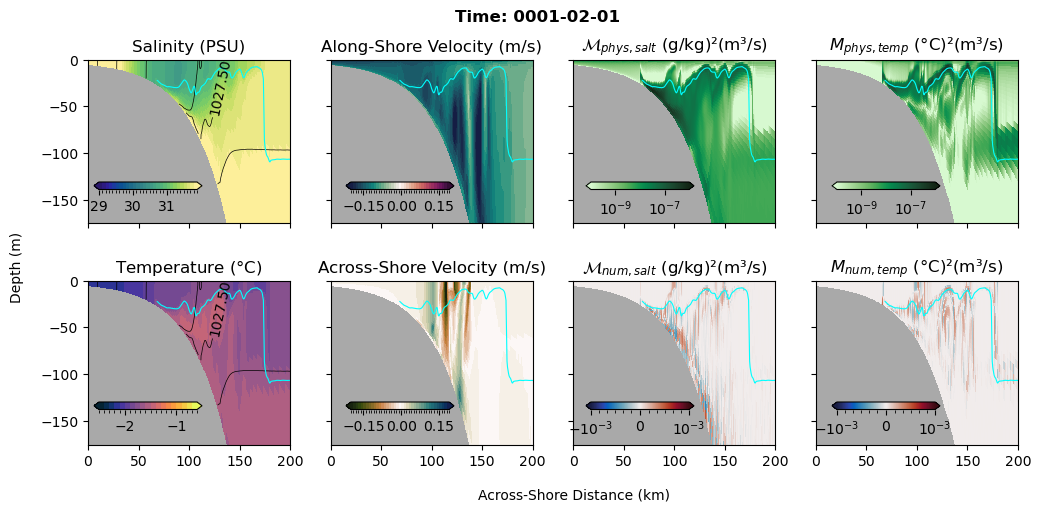

In [58]:
# Make a plot with all of the things 

# Set density levels
lev_dens = np.arange(1024, 1030, 0.5)

# Make the figure 
fig, ax = plt.subplots(2, 4, figsize=(12,5))

# Set limits to focus on the jet
for r in range(4):
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)
        ax[j,r].set_facecolor('darkgray')
        #ax[j,r].set_aspect(1.0) # don't think this makes sense here since depth is m and across-shore is km

        # Plot density contours
        if r == 0:
            y_2d = np.tile(y_rho, (ds.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
            c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx1,:,:,x_tran1], roms_density[time_idx1,:,:,x_tran1],
                    colors='black', linewidths=0.5, levels=lev_dens)
            ax[j,r].clabel(c1, inline=True, fmt='%1.2f')


# Plot Salt
p1 = ax[0,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx_1mon,:,:,x_tran1], ds.salt[time_idx_1mon,:,:,x_tran1],
                        cmap=cmap_salt, norm=norm_salt)
# Add colorbar
#plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
cbar_ax1 = fig.add_axes([0.13,0.62,0.09,0.015])
fig.colorbar(p1,ax=ax,extend='both', ticks=[29, 30, 31, 32], # label='Salinity (PSU)', 
             pad=0.03, orientation='horizontal', cax=cbar_ax1)
# Plot mixed layer depth
c1b = ax[0,0].plot(y_rho/1000,  mld*(-1),
                      color='aqua', linewidth=0.8)

# Plot temp
p2 = ax[1,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx_1mon,:,:,x_tran1], ds.temp[time_idx_1mon,:,:,x_tran1],
                        cmap=cmap_temp, norm=norm_temp)
cbar_ax2 = fig.add_axes([0.13,0.18,0.09,0.015])
fig.colorbar(p2,ax=ax,extend='both', ticks=[-1, -2, -3, -4], # label='Temperature ($\degree$C)', 
             pad=0.03, orientation='horizontal', cax=cbar_ax2)
# Plot mixed layer depth
c2b = ax[1,0].plot(y_rho/1000,  mld*(-1),
                      color='aqua', linewidth=0.8)

# Plot u
p3 = ax[0,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx_1mon,:,:,x_tran1], u_rho[time_idx_1mon,:,:,x_tran1],
                        cmap=cmap_u, norm=norm_cur)
# Add colorbar
#plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
cbar_ax3 = fig.add_axes([0.34,0.62,0.09,0.015])
fig.colorbar(p3,ax=ax,extend='both', ticks=[-0.15, 0, 0.15], # label='Along-Shore \nCurrent Velocity (m/s)',
             pad=0.03, orientation='horizontal', cax=cbar_ax3)
# Plot mixed layer depth
c3b = ax[0,1].plot(y_rho/1000,  mld*(-1),
                      color='aqua', linewidth=0.8)

# Plot v
p4 = ax[1,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], v_rho[time_idx1,:,:,x_tran1],
                        cmap=cmap_v, norm=norm_cur)
#plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
cbar_ax4 = fig.add_axes([0.34,0.18,0.09,0.015])
fig.colorbar(p4,ax=ax,extend='both', ticks=[-0.15, 0, 0.15], # label='Across-Shore \nCurrent Velocity (m/s)', 
             pad=0.03, orientation='horizontal', cax=cbar_ax4)
# Plot mixed layer depth
c4b = ax[1,1].plot(y_rho/1000,  mld*(-1),
                      color='aqua', linewidth=0.8)

# Plot salt mixing - physical
p5 = ax[0,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx_1mon,:,:,x_tran1], mphys_tran1_1mon[:,:],
                        cmap=cmap_mix_phy, norm=norm_mix_phy)
#plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
cbar_ax5 = fig.add_axes([0.54,0.62,0.09,0.015])
fig.colorbar(p5,ax=ax,extend='both', ticks=[1e-9, 1e-7],
             pad=0.03, orientation='horizontal', cax=cbar_ax5)
# Plot mixed layer depth
c5b = ax[0,2].plot(y_rho/1000,  mld*(-1),
                      color='aqua', linewidth=0.8)

# Plot salt mixing - numerical 
p6 = ax[1,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx_1mon,:,:,x_tran1], mnum_salt_dv_tran1_1mon[:,:],
                         cmap=cmap_mix_num, norm=norm_mix_num)
cbar_ax6 = fig.add_axes([0.54,0.18,0.09,0.015])
fig.colorbar(p6,ax=ax,extend='both', ticks=[-1e-3, 0, 1e-3],
             pad=0.03, orientation='horizontal', cax=cbar_ax6)
# Plot mixed layer depth
c6b = ax[1,2].plot(y_rho/1000,  mld*(-1),
                      color='aqua', linewidth=0.8)

# Plot temp mixing - physical 
p7 = ax[0,3].pcolormesh(y_rho/1000, ds.z_rho[time_idx_1mon,:,:,x_tran1], mphyt_tran1_1mon[:,:],
                         cmap=cmap_mix_phy, norm=norm_mix_phy)
cbar_ax7 = fig.add_axes([0.745,0.62,0.09,0.015])
fig.colorbar(p7,ax=ax,extend='both', ticks=[1e-9, 1e-7],
             pad=0.03, orientation='horizontal', cax=cbar_ax7)
# Plot mixed layer depth
c7b = ax[0,3].plot(y_rho/1000,  mld*(-1),
                      color='aqua', linewidth=0.8)

# Plot temp mixing - numerical 
p8 = ax[1,3].pcolormesh(y_rho/1000, ds.z_rho[time_idx_1mon,:,:,x_tran1], mnum_temp_dv_tran1_1mon[:,:],
                         cmap=cmap_mix_num, norm=norm_mix_num)
cbar_ax8 = fig.add_axes([0.745,0.18,0.09,0.015])
fig.colorbar(p8,ax=ax,extend='both', ticks=[-1e-3, 0, 1e-3],
             pad=0.03, orientation='horizontal', cax=cbar_ax8)
# Plot mixed layer depth
c8b = ax[1,3].plot(y_rho/1000,  mld*(-1),
                      color='aqua', linewidth=0.8)


# Label the plots/axes
ax[0,0].set_title('Salinity (PSU)') #, weight='bold')
ax[1,0].set_title('Temperature ($\degree$C)') #, weight='bold')
ax[0,1].set_title('Along-Shore Velocity (m/s)') #, weight='bold')
ax[1,1].set_title('Across-Shore Velocity (m/s)') #, weight='bold')
ax[0,2].set_title('$\mathcal{M}_{phys,salt}$ (g/kg)\u00b2(m\u00b3/s)') #, weight='bold')
ax[1,2].set_title('$\mathcal{M}_{num,salt}$ (g/kg)\u00b2(m\u00b3/s)') #, weight='bold')
ax[0,3].set_title('$M_{phys,temp}$ ($\degree$C)\u00b2(m\u00b3/s)') #, weight='bold')
ax[1,3].set_title('$M_{num,temp}$ ($\degree$C)\u00b2(m\u00b3/s)') #, weight='bold')

fig.suptitle('Time: ' + str(ds.ocean_time[time_idx_1mon].values)[:10], weight='bold')
fig.text(0.45, 0.001, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Set the spacing
plt.subplots_adjust(hspace=0.35)

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
plt.setp(ax[0,3].get_xticklabels(), visible=False)
plt.setp(ax[0,3].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)
plt.setp(ax[1,3].get_yticklabels(), visible=False)


In [45]:
# Make a function to plot this as a movie? orrr just do snapshots for nowwwww
# but no a movie would be super dope so do that

In [59]:
# Now define function to plot the movie
def plot_salt_temp_uv_mix(time_idx):
    i = time_idx // 1
    #print('i: ', i)
    #print('time_idx: ', time_idx)

    # Get all the things for this time and transect
    # Mixed layer depth
    # Find where the math equals 0.0
    iso_array = (roms_density[time_idx,:,:,x_tran1] - 
                roms_density[time_idx,-1,:,x_tran1] - 0.03)
    # Use the grid object to find the Z value at the 0.0 crossing
    # This replicates isoslice but gives you a "clean" DataArray back
    mld = grid.transform(
        ds.z_rho[time_idx,:,:,x_tran1], # The values we want (depth)
        'Z',                                               # The axis to search along
        np.array([0.0]),                                             # The target value in iso_array
        target_data=iso_array                              # The array to search through
    )
    # The transform returns a dimension for the target value (0.0), so we squeeze it out
    mld = abs(mld.squeeze())

    # Physical mixing
    # Salinity (2-hourly)
    mphys_tran1_at_time_idx = (Akr_rho).isel(xi_rho=x_tran1, ocean_time=time_idx).compute()
    mphys_tran1_at_time_idx.attrs = ''
    # Temperature (2-hourly)
    mphyt_tran1_at_time_idx = (Akrt_rho).isel(xi_rho=x_tran1, ocean_time=time_idx).compute()
    mphyt_tran1_at_time_idx.attrs = ''

    # Numerical mixing
    # Salinity 
    mnum_salt_dv_tran1_at_time_idx = (ds.dye_03).isel(xi_rho=x_tran1, ocean_time=time_idx).compute()
    # Temperature
    mnum_temp_dv_tran1_at_time_idx = (ds.dye_06).isel(xi_rho=x_tran1, ocean_time=time_idx).compute()


    # Make the figure 
    fig, ax = plt.subplots(2, 4, figsize=(12,5))

    # Set limits to focus on the jet
    for r in range(4):
        for j in range(2):
            # Set the limits
            ax[j,r].set_xlim(0,200)
            ax[j,r].set_ylim(-175,0)
            ax[j,r].set_facecolor('darkgray')
            #ax[j,r].set_aspect(1.0) # don't think this makes sense here since depth is m and across-shore is km

            # Plot density contours
            if r == 0:
                y_2d = np.tile(y_rho, (ds.z_rho[time_idx,:,:,x_tran1].shape[0], 1))
                c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx,:,:,x_tran1], roms_density[time_idx,:,:,x_tran1],
                        colors='black', linewidths=0.5, levels=lev_dens)
                ax[j,r].clabel(c1, inline=True, fmt='%1.2f')


    # Plot Salt
    p1 = ax[0,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], ds.salt[time_idx,:,:,x_tran1],
                            cmap=cmap_salt, norm=norm_salt)
    # Add colorbar
    #plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
    cbar_ax1 = fig.add_axes([0.13,0.62,0.09,0.015])
    fig.colorbar(p1,ax=ax,extend='both', ticks=[29, 30, 31, 32], # label='Salinity (PSU)', 
                pad=0.03, orientation='horizontal', cax=cbar_ax1)
    # Plot mixed layer depth
    c1b = ax[0,0].plot(y_rho/1000,  mld*(-1),
                        color='aqua', linewidth=0.8)

    # Plot temp
    p2 = ax[1,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], ds.temp[time_idx,:,:,x_tran1],
                            cmap=cmap_temp, norm=norm_temp)
    cbar_ax2 = fig.add_axes([0.13,0.18,0.09,0.015])
    fig.colorbar(p2,ax=ax,extend='both', ticks=[-1, -2, -3, -4], # label='Temperature ($\degree$C)', 
                pad=0.03, orientation='horizontal', cax=cbar_ax2)
    # Plot mixed layer depth
    c2b = ax[1,0].plot(y_rho/1000,  mld*(-1),
                        color='aqua', linewidth=0.8)

    # Plot u
    p3 = ax[0,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], u_rho[time_idx,:,:,x_tran1],
                            cmap=cmap_u, norm=norm_cur)
    # Add colorbar
    #plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
    cbar_ax3 = fig.add_axes([0.34,0.62,0.09,0.015])
    fig.colorbar(p3,ax=ax,extend='both', ticks=[-0.15, 0, 0.15], # label='Along-Shore \nCurrent Velocity (m/s)',
                pad=0.03, orientation='horizontal', cax=cbar_ax3)
    # Plot mixed layer depth
    c3b = ax[0,1].plot(y_rho/1000,  mld*(-1),
                        color='aqua', linewidth=0.8)

    # Plot v
    p4 = ax[1,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], v_rho[time_idx,:,:,x_tran1],
                            cmap=cmap_v, norm=norm_cur)
    #plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
    cbar_ax4 = fig.add_axes([0.34,0.18,0.09,0.015])
    fig.colorbar(p4,ax=ax,extend='both', ticks=[-0.15, 0, 0.15], # label='Across-Shore \nCurrent Velocity (m/s)', 
                pad=0.03, orientation='horizontal', cax=cbar_ax4)
    # Plot mixed layer depth
    c4b = ax[1,1].plot(y_rho/1000,  mld*(-1),
                        color='aqua', linewidth=0.8)

    # Plot salt mixing - physical
    p5 = ax[0,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], mphys_tran1_at_time_idx[:,:],
                            cmap=cmap_mix_phy, norm=norm_mix_phy)
    #plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
    cbar_ax5 = fig.add_axes([0.54,0.62,0.09,0.015])
    fig.colorbar(p5,ax=ax,extend='both', ticks=[1e-9, 1e-7],
                pad=0.03, orientation='horizontal', cax=cbar_ax5)
    # Plot mixed layer depth
    c5b = ax[0,2].plot(y_rho/1000,  mld*(-1),
                        color='aqua', linewidth=0.8)

    # Plot salt mixing - numerical 
    p6 = ax[1,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], mnum_salt_dv_tran1_at_time_idx[:,:],
                            cmap=cmap_mix_num, norm=norm_mix_num)
    cbar_ax6 = fig.add_axes([0.54,0.18,0.09,0.015])
    fig.colorbar(p6,ax=ax,extend='both', ticks=[-1e-3, 0, 1e-3],
                pad=0.03, orientation='horizontal', cax=cbar_ax6)
    # Plot mixed layer depth
    c6b = ax[1,2].plot(y_rho/1000,  mld*(-1),
                        color='aqua', linewidth=0.8)

    # Plot temp mixing - physical 
    p7 = ax[0,3].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], mphyt_tran1_at_time_idx[:,:],
                            cmap=cmap_mix_phy, norm=norm_mix_phy)
    cbar_ax7 = fig.add_axes([0.745,0.62,0.09,0.015])
    fig.colorbar(p7,ax=ax,extend='both', ticks=[1e-9, 1e-7],
                pad=0.03, orientation='horizontal', cax=cbar_ax7)
    # Plot mixed layer depth
    c7b = ax[0,3].plot(y_rho/1000,  mld*(-1),
                        color='aqua', linewidth=0.8)

    # Plot temp mixing - numerical 
    p8 = ax[1,3].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], mnum_temp_dv_tran1_at_time_idx[:,:],
                            cmap=cmap_mix_num, norm=norm_mix_num)
    cbar_ax8 = fig.add_axes([0.745,0.18,0.09,0.015])
    fig.colorbar(p8,ax=ax,extend='both', ticks=[-1e-3, 0, 1e-3],
                pad=0.03, orientation='horizontal', cax=cbar_ax8)
    # Plot mixed layer depth
    c8b = ax[1,3].plot(y_rho/1000,  mld*(-1),
                        color='aqua', linewidth=0.8)


    # Label the plots/axes
    ax[0,0].set_title('Salinity (PSU)') #, weight='bold')
    ax[1,0].set_title('Temperature ($\degree$C)') #, weight='bold')
    ax[0,1].set_title('Along-Shore Velocity (m/s)') #, weight='bold')
    ax[1,1].set_title('Across-Shore Velocity (m/s)') #, weight='bold')
    ax[0,2].set_title('$\mathcal{M}_{phys,salt}$ (g/kg)\u00b2(m\u00b3/s)') #, weight='bold')
    ax[1,2].set_title('$\mathcal{M}_{num,salt}$ (g/kg)\u00b2(m\u00b3/s)') #, weight='bold')
    ax[0,3].set_title('$M_{phys,temp}$ ($\degree$C)\u00b2(m\u00b3/s)') #, weight='bold')
    ax[1,3].set_title('$M_{num,temp}$ ($\degree$C)\u00b2(m\u00b3/s)') #, weight='bold')

    fig.suptitle('Time: ' + str(ds.ocean_time[time_idx].values)[:10], weight='bold')
    fig.text(0.45, 0.001, 'Across-Shore Distance (km)')
    fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

    # Set the spacing
    plt.subplots_adjust(hspace=0.35)

    # Hide some axis labels 
    plt.setp(ax[0,1].get_xticklabels(), visible=False)
    plt.setp(ax[0,1].get_yticklabels(), visible=False)
    plt.setp(ax[0,2].get_xticklabels(), visible=False)
    plt.setp(ax[0,2].get_yticklabels(), visible=False)
    plt.setp(ax[0,3].get_xticklabels(), visible=False)
    plt.setp(ax[0,3].get_yticklabels(), visible=False)
    plt.setp(ax[0,0].get_xticklabels(), visible=False)
    plt.setp(ax[1,1].get_yticklabels(), visible=False)
    plt.setp(ax[1,2].get_yticklabels(), visible=False)
    plt.setp(ax[1,3].get_yticklabels(), visible=False)

    # Comment this out if you are printing a lot of frames... jupyter will be unhappy
    #print(f'/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Movies/Surf_temp_salt_vort_ice/Plots01/surf_temp_salt_aice_icethick_rvort_tnum_{i}.png')
   
    plt.savefig(
        f'/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Movies/Salt_temp_uv_mix/Plots01/salt_temp_uv_mix_const_u3c4_keps_{i}.png',
        dpi=200, bbox_inches='tight'
    )
    plt.close(fig)  # Close to avoid memory leaks


In [60]:
# Call the function to plot
Parallel(n_jobs=4)(delayed(plot_salt_temp_uv_mix)(time_idx) for time_idx in range(0, len(ds.ocean_time), 1))

/global/homes/b/bundzis/.conda/envs/xroms/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/global/homes/b/bundzis/.conda/envs/xroms/lib/python3.11/site-packages/xgcm/grid.py:1026: UserWarning: Input`target_data` has no name, but we need a name for the transformed dimension. The name `TRANSFORMED_DIMENSION` will be used. To avoid this warning, call `.rename` on `target_data` before calling `transform`.
  warnings.warn(
/global/homes/b/bundzis/.conda/envs/xroms/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/global/homes/b/bundzis/.conda/envs/xroms/lib/python3.11/site-packages/xgc

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,